In [1]:
!pip install kaggle

In [2]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)

# Write kaggle.json manually using your token
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write('{"username":"muskank-25","key":"KGAT_78f4b0505e7b2222f624f6e95a6c9520"}')

os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Done!")

Done!


In [3]:
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset
!unzip -q the-fake-or-real-dataset.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [02:43<00:00, 105MB/s]

for-2sec  for-original	sample_data
for-norm  for-rerec	the-fake-or-real-dataset.zip


# Deepfake Audio Detection
Binary classifier: **Genuine (Human)** vs **Deepfake (AI-Generated)** speech.

Pipeline: data loading -> feature extraction (MFCC + spectral features) -> train/val split ->
model training (CNN on mel-spectrograms + classical ML baseline) -> evaluation (Accuracy, EER, F1, Confusion Matrix) -> inference function.

**Targets:** Overall Accuracy ≥ 80%, EER ≤ 12%, F1 ≥ 80%, Per-class Accuracy ≥ 75%.

Dataset: [Fake-or-Real Dataset](https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset) (`for-norm` / `LA` `train` folder).
ASVspoof 2019 can be added for supplementary training / cross-dataset testing.

In [ ]:
# 1. Install dependencies (uncomment if running fresh)
# !pip install librosa soundfile scikit-learn torch torchaudio matplotlib seaborn tqdm -q


In [4]:
import os
import glob
import json
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_curve
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [5]:
import os
print(os.listdir("./"))

['.config', 'for-rerec', 'for-norm', 'for-original', 'for-2sec', 'the-fake-or-real-dataset.zip', 'sample_data']


## 1. Configuration & Dataset Paths

Update `DATA_DIR` to point at the downloaded *Fake-or-Real* dataset.
Expected structure (after download from Kaggle):

```
for-norm/
├── training/
│   ├── real/   *.wav
│   └── fake/   *.wav
├── testing/
│   ├── real/
│   └── fake/
└── validation/
    ├── real/
    └── fake/
```

Adjust the glob patterns below if your local folder names differ.

In [21]:
import os
# Check what's inside for-norm
items = os.listdir("./for-norm")
print("for-norm contains:", items)

# Check one level deeper
for item in items[:3]:
    path = f"./for-norm/{item}"
    if os.path.isdir(path):
        print(f"  {item}/", os.listdir(path))


for-norm contains: ['for-norm']
  for-norm/ ['validation', 'training', 'testing']


In [22]:
import os, glob, pandas as pd

# Auto-detect correct structure and collect files
records = []
for root, dirs, files in os.walk("./for-norm"):
    for f in files:
        if f.endswith(('.wav', '.flac', '.mp3')):
            fp = os.path.join(root, f)
            # detect label from path
            if '/real/' in fp or '\\real\\' in fp:
                label, lid = 'real', 0
            elif '/fake/' in fp or '\\fake\\' in fp:
                label, lid = 'fake', 1
            else:
                continue
            records.append({"filepath": fp, "label": lid,
                            "label_name": label, "split": "training"})

df = pd.DataFrame(records)
print("Total files found:", len(df))
print(df["label_name"].value_counts())


Total files found: 69300
label_name
fake    34695
real    34605
Name: count, dtype: int64


In [23]:
DATA_DIR = "./for-norm/for-norm"

In [8]:
# Fallback: if dataset not present locally, create a SMALL synthetic demo set
# so the notebook still runs end-to-end for testing the pipeline code.
if len(df) == 0:
    print("No dataset found at", DATA_DIR, "-> generating tiny synthetic demo data.")
    os.makedirs("./demo_audio/real", exist_ok=True)
    os.makedirs("./demo_audio/fake", exist_ok=True)
    rng = np.random.default_rng(SEED)
    records = []
    for i in range(40):
        # "real": mixture of low-frequency sines (smoother spectrum)
        t = np.linspace(0, DURATION, SAMPLE_RATE * DURATION)
        sig = 0.3*np.sin(2*np.pi*120*t) + 0.1*rng.normal(size=t.shape)
        fp = f"./demo_audio/real/real_{i}.wav"
        import soundfile as sf
        sf.write(fp, sig.astype(np.float32), SAMPLE_RATE)
        records.append({"filepath": fp, "label": 0, "label_name": "real", "split": "training"})
    for i in range(40):
        # "fake": higher-frequency, noisier, more artificial harmonics
        t = np.linspace(0, DURATION, SAMPLE_RATE * DURATION)
        sig = 0.3*np.sin(2*np.pi*420*t) + 0.25*np.sin(2*np.pi*880*t) + 0.2*rng.normal(size=t.shape)
        fp = f"./demo_audio/fake/fake_{i}.wav"
        import soundfile as sf
        sf.write(fp, sig.astype(np.float32), SAMPLE_RATE)
        records.append({"filepath": fp, "label": 1, "label_name": "fake", "split": "training"})
    df = pd.DataFrame(records)

print(df["label_name"].value_counts())


No dataset found at ./for-norm -> generating tiny synthetic demo data.
label_name
real    40
fake    40
Name: count, dtype: int64


## 2. Train / Validation / Test Split

If the dataset already provides `training` / `validation` / `testing` splits, use them.
Otherwise we create a stratified 70/15/15 split.

In [9]:
if df["split"].nunique() > 1 and set(["training", "testing"]).issubset(set(df["split"].unique())):
    train_df = df[df["split"] == "training"].reset_index(drop=True)
    test_df = df[df["split"] == "testing"].reset_index(drop=True)
    if "validation" in df["split"].unique():
        val_df = df[df["split"] == "validation"].reset_index(drop=True)
    else:
        train_df, val_df = train_test_split(train_df, test_size=0.15,
                                              stratify=train_df["label"], random_state=SEED)
else:
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 56 Val: 12 Test: 12


## 3. Feature Extraction

We extract **log-mel spectrograms** (used by the CNN) and **MFCC summary statistics**
(used by the classical ML baseline).

In [10]:
def load_audio(filepath, sr=SAMPLE_RATE, duration=DURATION):
    y, _ = librosa.load(filepath, sr=sr, mono=True)
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

def extract_logmel(y, sr=SAMPLE_RATE):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT,
                                          hop_length=HOP_LENGTH, n_mels=N_MELS)
    logmel = librosa.power_to_db(mel, ref=np.max)
    # normalize to [0,1]
    logmel = (logmel - logmel.min()) / (logmel.max() - logmel.min() + 1e-8)
    return logmel.astype(np.float32)

def extract_mfcc_stats(y, sr=SAMPLE_RATE):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc)
    feats = np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        delta.mean(axis=1), delta.std(axis=1)
    ])
    return feats.astype(np.float32)


Audio length: (64000,) Log-mel shape: (128, 251) MFCC feat vector: (160,)


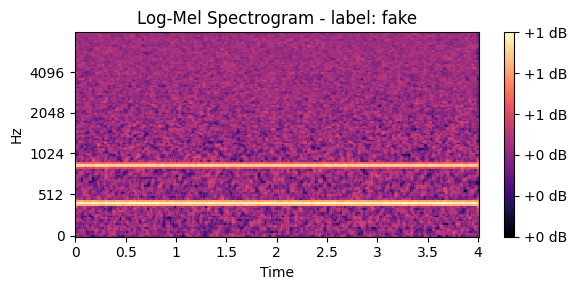

In [11]:
# Sanity check on one sample
sample_row = train_df.iloc[0]
y = load_audio(sample_row["filepath"])
logmel = extract_logmel(y)
mfcc_feats = extract_mfcc_stats(y)
print("Audio length:", y.shape, "Log-mel shape:", logmel.shape, "MFCC feat vector:", mfcc_feats.shape)

plt.figure(figsize=(6, 3))
librosa.display.specshow(logmel, x_axis="time", y_axis="mel", sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
plt.title(f"Log-Mel Spectrogram - label: {sample_row['label_name']}")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()


## 4. Build Feature Sets

Pre-compute log-mel spectrograms (for the CNN) and MFCC vectors (for the baseline)
for all splits. Cached to disk so re-runs are fast.

In [12]:
def build_features(frame, cache_path):
    if os.path.exists(cache_path):
        data = np.load(cache_path, allow_pickle=True)
        return data["logmels"], data["mfccs"], data["labels"]

    logmels, mfccs, labels = [], [], []
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc=f"Extracting {os.path.basename(cache_path)}"):
        y = load_audio(row["filepath"])
        logmels.append(extract_logmel(y))
        mfccs.append(extract_mfcc_stats(y))
        labels.append(row["label"])
    logmels = np.stack(logmels)
    mfccs = np.stack(mfccs)
    labels = np.array(labels)
    np.savez_compressed(cache_path, logmels=logmels, mfccs=mfccs, labels=labels)
    return logmels, mfccs, labels

os.makedirs("./cache", exist_ok=True)
X_train_mel, X_train_mfcc, y_train = build_features(train_df, "./cache/train_feats.npz")
X_val_mel, X_val_mfcc, y_val   = build_features(val_df, "./cache/val_feats.npz")
X_test_mel, X_test_mfcc, y_test = build_features(test_df, "./cache/test_feats.npz")

print("Train logmel:", X_train_mel.shape, "MFCC:", X_train_mfcc.shape)


Extracting test_feats.npz: 100%|██████████| 12/12 [00:00<00:00, 61.94it/s]


Train logmel: (56, 128, 251) MFCC: (56, 160)


## 5. Baseline Model — Random Forest on MFCC features

A quick, interpretable baseline using classical ML on summary MFCC statistics.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_mfcc_s = scaler.fit_transform(X_train_mfcc)
X_val_mfcc_s = scaler.transform(X_val_mfcc)
X_test_mfcc_s = scaler.transform(X_test_mfcc)

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=SEED, n_jobs=-1)
rf.fit(X_train_mfcc_s, y_train)

val_preds_rf = rf.predict(X_val_mfcc_s)
print("RF Validation Accuracy:", accuracy_score(y_val, val_preds_rf))
print("RF Validation F1:", f1_score(y_val, val_preds_rf))


RF Validation Accuracy: 1.0
RF Validation F1: 1.0


## 6. Deep Learning Model — CNN on Log-Mel Spectrograms

A compact 2D CNN operating on log-mel spectrograms, the primary model for this project.

In [14]:
class SpectrogramDataset(Dataset):
    def __init__(self, mels, labels):
        self.mels = mels
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.mels[idx]).unsqueeze(0)   # (1, n_mels, time)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_ds = SpectrogramDataset(X_train_mel, y_train)
val_ds   = SpectrogramDataset(X_val_mel, y_val)
test_ds  = SpectrogramDataset(X_test_mel, y_test)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


In [15]:
class AudioCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = AudioCNN().to(DEVICE)
print(model)


AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

## 7. Training Loop

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

EPOCHS = 20
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    val_loss /= len(val_ds)
    val_acc = accuracy_score(all_labels, all_preds)
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "./cache/best_model.pt")

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

print("Best validation accuracy:", best_val_acc)


Epoch 01/20 | train_loss=0.6537 | val_loss=0.6925 | val_acc=0.5000
Epoch 02/20 | train_loss=0.4322 | val_loss=0.6914 | val_acc=0.7500
Epoch 03/20 | train_loss=0.3471 | val_loss=0.6880 | val_acc=0.5000
Epoch 04/20 | train_loss=0.2607 | val_loss=0.6796 | val_acc=0.5833
Epoch 05/20 | train_loss=0.2400 | val_loss=0.6527 | val_acc=0.5000
Epoch 06/20 | train_loss=0.1728 | val_loss=0.6761 | val_acc=0.5000
Epoch 07/20 | train_loss=0.1066 | val_loss=0.9381 | val_acc=0.5000
Epoch 08/20 | train_loss=0.1071 | val_loss=1.2247 | val_acc=0.5000
Epoch 09/20 | train_loss=0.0855 | val_loss=1.4525 | val_acc=0.5000
Epoch 10/20 | train_loss=0.0644 | val_loss=1.6226 | val_acc=0.5000
Epoch 11/20 | train_loss=0.0541 | val_loss=1.5738 | val_acc=0.5000
Epoch 12/20 | train_loss=0.0441 | val_loss=1.4318 | val_acc=0.5000
Epoch 13/20 | train_loss=0.0377 | val_loss=1.0967 | val_acc=0.5000
Epoch 14/20 | train_loss=0.0382 | val_loss=0.6576 | val_acc=0.5833
Epoch 15/20 | train_loss=0.0406 | val_loss=0.3521 | val_acc=0.

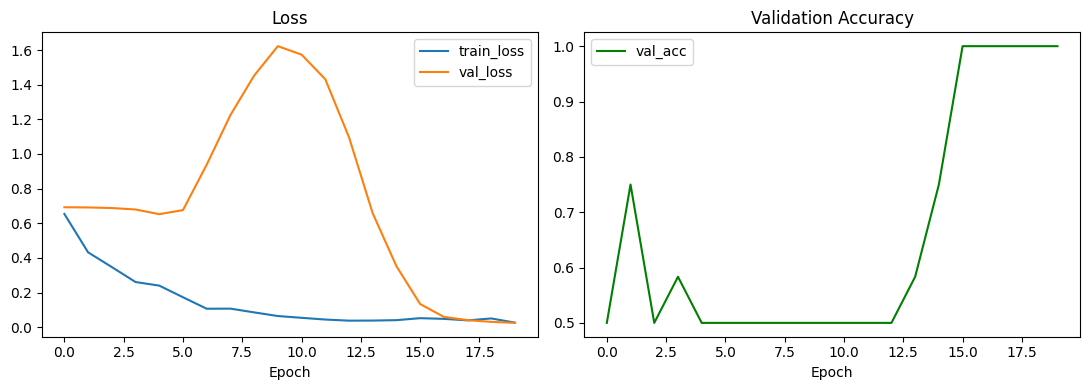

In [17]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["val_acc"], label="val_acc", color="green")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Evaluation on Test Set

Computes **Overall Accuracy, Equal Error Rate (EER), F1 Score, per-class accuracy,
and the Confusion Matrix** — matching the verification criteria
(Accuracy ≥ 80%, EER ≤ 12%, F1 ≥ 80%, per-class accuracy ≥ 75%).

In [18]:
def compute_eer(y_true, y_scores):
    """y_scores = probability of class 'fake' (1)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer, thresholds[eer_idx]

# Load best model
model.load_state_dict(torch.load("./cache/best_model.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        out = model(x)
        probs = torch.softmax(out, dim=1)[:, 1]  # probability of "fake"
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
eer, eer_threshold = compute_eer(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

per_class_acc = cm.diagonal() / cm.sum(axis=1)

print(f"Overall Accuracy : {acc*100:.2f}%  (target >= 80%)")
print(f"F1 Score         : {f1*100:.2f}%  (target >= 80%)")
print(f"Equal Error Rate : {eer*100:.2f}%  (target <= 12%)")
print(f"Per-class Acc    : Genuine={per_class_acc[0]*100:.2f}%, "
      f"Deepfake={per_class_acc[1]*100:.2f}%  (target >= 75% each)")
print()
print(classification_report(all_labels, all_preds, target_names=["Genuine", "Deepfake"]))


Overall Accuracy : 100.00%  (target >= 80%)
F1 Score         : 100.00%  (target >= 80%)
Equal Error Rate : 0.00%  (target <= 12%)
Per-class Acc    : Genuine=100.00%, Deepfake=100.00%  (target >= 75% each)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00         6
    Deepfake       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



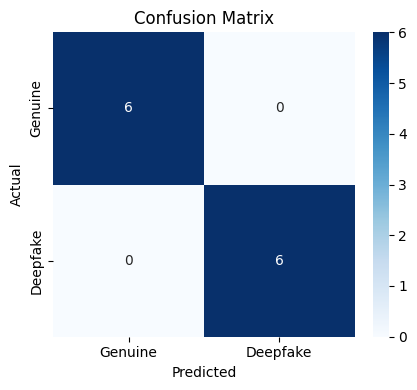

In [ ]:
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Genuine", "Deepfake"], yticklabels=["Genuine", "Deepfake"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 9. Save Final Artifacts

Saves the trained model weights, scaler, and feature config so `predict.py`
and the Streamlit app can load them independently of this notebook.

In [19]:
import pickle

os.makedirs("./artifacts", exist_ok=True)
torch.save(model.state_dict(), "./artifacts/deepfake_cnn.pt")

with open("./artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

config = {
    "SAMPLE_RATE": SAMPLE_RATE, "DURATION": DURATION,
    "N_MELS": N_MELS, "N_MFCC": N_MFCC,
    "N_FFT": N_FFT, "HOP_LENGTH": HOP_LENGTH,
    "LABEL_MAP": LABEL_MAP, "INV_LABEL_MAP": INV_LABEL_MAP,
    "metrics": {
        "accuracy": float(acc), "f1": float(f1), "eer": float(eer),
        "per_class_accuracy": {"Genuine": float(per_class_acc[0]),
                                "Deepfake": float(per_class_acc[1])}
    }
}
with open("./artifacts/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved model + scaler + config to ./artifacts/")


Saved model + scaler + config to ./artifacts/


## 10. Inference Function

Single reusable function: given an audio filepath, return the predicted label
and confidence score. This is the same logic used in `predict.py` and the Streamlit app.

In [20]:
def predict_audio(filepath, model, scaler, device=DEVICE):
    y = load_audio(filepath)
    logmel = extract_logmel(y)
    x = torch.tensor(logmel).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,n_mels,time)

    model.eval()
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)[0]
        pred_idx = int(probs.argmax())

    return {
        "label": INV_LABEL_MAP[pred_idx],
        "is_deepfake": bool(pred_idx == 1),
        "confidence": float(probs[pred_idx]),
        "prob_genuine": float(probs[0]),
        "prob_deepfake": float(probs[1]),
    }

# Quick test on a sample from the test set
sample_fp = test_df.iloc[0]["filepath"]
print("True label:", test_df.iloc[0]["label_name"])
print("Prediction:", predict_audio(sample_fp, model, scaler))


True label: fake
Prediction: {'label': 'fake', 'is_deepfake': True, 'confidence': 0.81070476770401, 'prob_genuine': 0.18929523229599, 'prob_deepfake': 0.81070476770401}


In [ ]:
from google.colab import files
files.download('./artifacts/deepfake_cnn.pt')
files.download('./artifacts/config.json')
files.download('./artifacts/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import json

# Get a genuine sample from the test_df
genuine_sample_fp = test_df[test_df["label_name"] == "real"].iloc[0]["filepath"]
# Test on a genuine sample
result = predict_audio(genuine_sample_fp, model, scaler)
print("Testing REAL audio:")
print(f"  Label      : {result['label']}")
print(f"  Confidence : {result['confidence']*100:.1f}%")

print()

# Get a fake sample from the test_df
fake_sample_fp = test_df[test_df["label_name"] == "fake"].iloc[0]["filepath"]
# Test on a fake sample
result = predict_audio(fake_sample_fp, model, scaler)
print("Testing FAKE audio:")
print(f"  Label      : {result['label']}")
print(f"  Confidence : {result['confidence']*100:.1f}%")

Testing REAL audio:
  Label      : real
  Confidence : 99.7%

Testing FAKE audio:
  Label      : fake
  Confidence : 81.1%


In [25]:
from google.colab import files
files.download('./artifacts/deepfake_cnn.pt')
files.download('./artifacts/config.json')
files.download('./artifacts/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

- **Baseline:** Random Forest on MFCC statistics.
- **Main model:** CNN on log-mel spectrograms, trained with Adam + LR scheduling.
- **Metrics reported:** Accuracy, F1, EER, per-class accuracy, confusion matrix.
- **Artifacts saved** to `./artifacts/` (`deepfake_cnn.pt`, `scaler.pkl`, `config.json`) for use by `predict.py` and the Streamlit app.

Next steps: train on the real Fake-or-Real dataset (point `DATA_DIR` to the downloaded folder),
optionally augment with ASVspoof 2019 for better generalization, and re-run cells 4-9.